# CAVA Group (CAVA) - Data Collection
## Consumer Sector Case Study

This notebook collects data from three sources:
1. **Financial data** - Stock price + quarterly fundamentals via yfinance
2. **Google Trends** - Consumer interest proxy via pytrends
3. **Reddit sentiment** - Social media consumer sentiment via PRAW
4. **News sentiments** - News consumer sentiment via Finnhub
5. **Analyst ratings** - Analyst ratings / recommendations downgrade / upgrade via CapitalIQ

All data is saved to CSV for use in the modeling notebook.

In [ ]:
# Install dependencies (run once)
# !pip install yfinance pytrends praw pandas numpy matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

print('Libraries loaded.')

Libraries loaded.


---
## Part 1: Financial Data (yfinance)

#### Stock Data

In [26]:
import yfinance as yf

ticker = yf.Ticker('CAVA')

# CAVA IPO'd June 2023, so start from there
price_df = ticker.history(start='2023-06-15', end='2026-05-01', auto_adjust=True)
price_df = price_df[['Close', 'Volume']].reset_index()
price_df.columns = ['date', 'adj_close_price', 'volume']
price_df['date'] = pd.to_datetime(price_df['date']).dt.tz_localize(None)

print(f'Price data: {len(price_df)} rows, {price_df.date.min().date()} to {price_df.date.max().date()}')
price_df.head()

Price data: 721 rows, 2023-06-15 to 2026-04-30


,date,adj_close_price,volume
0,2023-06-15,43.779999,16751800
1,2023-06-16,38.150002,8417500
2,2023-06-20,38.430000,1607200
3,2023-06-21,38.340000,738600
4,2023-06-22,39.160000,2365600


### Quarterly Financial Results

In [5]:
# Source: CAVA earnings releases & 10-Q filings (SEC Edgar / IR site)
# Key metrics: Total Revenue, Same-Restaurant Sales Growth (SSSG), AUV, Restaurant Count
# Restaurant-Level Profit Margin, Digital Revenue Mix, Adjusted EBITDA Margin

# Data sourced from CAVA earnings releases:
# https://ir.cava.com/news-releases

quarterly_data = {
    'quarter': [
        'Q2 2022', 'Q3 2022', 'Q4 2022',
        'Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023',
        'Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024',
        'Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025'

    ],
    'period_end': [
        '2022-07-10', '2022-10-02', '2023-01-01',
        '2023-04-16', '2023-07-09', '2023-10-01', '2023-12-31',
        '2024-04-21', '2024-07-14', '2024-10-06', '2024-12-29',
        '2025-04-20', '2025-07-13', '2025-10-05', '2025-12-28'
    ],
    # Total revenue ($M)
    'revenue_m': [
        135.9, 139.3, 123.0,
        196.8, 172.9, 175.6, 177.2,
        259.0, 233.5, 243.8, 227.4,
        331.8, 280.6, 292.2, 275.0
    ],
    # Same-restaurant sales growth (%) - YoY
    'sssg_pct': [
        13.3, 9.2, 14.8,
        28.4, 18.2, 14.1, 11.4,
        2.3, 14.4, 18.1, 21.2,
        10.8, 2.1, 1.9, 0.5
    ],
    # Average Unit Volume
    'auv_in_thousands': [
        2399, 2383, 2398,
        2547, 2599, 2640, 2639,
        2608, 2689, 2784, 2865,
        2933, 2939, 2935, 2934
    ],
    # Restaurant-level profit margin (%)
    'restaurant_margin_pct': [
        22.1, 21.7, 20.0,
        25.4, 26.1, 25.1, 22.4,
        25.2, 26.5, 25.6, 22.4,
        25.1, 26.3, 24.6, 21.4
    ],
    # Number of restaurants (end of period)
    'restaurant_count': [
        195, 214, 237,
        263, 279, 290, 309,
        323, 341, 352, 367,
        382, 398, 415, 439
    ],
    'net_new_openings': [
        18, 19, 23, 
        26, 16, 11, 19, 
        14, 18, 11, 15, 
        15, 16, 17, 24
    ],
    'digital_revenue_mix_pct': [
        33.9, 32.9, 34.5, #missing 2022Q4 number, used 2022FY number as proxy
        36.6, 36.1, 35.5, 35.9,
        37.0, 35.8, 35.8, 36.8,
        38.0, 37.3, 37.6, 38.9
    ],
    'adj_ebitda_margin_pct': [
        4.3, 3.5, 2.7,
        8.2, 12.5, 11.3, 8.9,
        12.9, 14.7, 13.7, 11.0,
        13.5, 15.0, 13.7, 9.4
    ],
    'weeks_in_period': [
    12, 12, 12,   # Q2-Q4 2022
    16, 12, 12, 13,  # 2023, Q4 2023 includes 13th week
    16, 12, 12, 12,   # 2024
    16, 12, 12, 12   # 2025
],
}

q_df = pd.DataFrame(quarterly_data)
q_df['period_end'] = pd.to_datetime(q_df['period_end'])
q_df['weekly_revenue_m'] = q_df['revenue_m'] / q_df['weeks_in_period']
q_df = q_df.sort_values('period_end').reset_index(drop=True)
print('Quarterly fundamentals loaded:')
q_df

Quarterly fundamentals loaded:


,quarter,period_end,revenue_m,sssg_pct,auv_in_thousands,restaurant_margin_pct,restaurant_count,net_new_openings,digital_revenue_mix_pct,adj_ebitda_margin_pct,weeks_in_period,weekly_revenue_m
0,Q2 2022,2022-07-10,135.9,13.3,2399,22.1,195,18,33.9,4.3,12,11.325000
1,Q3 2022,2022-10-02,139.3,9.2,2383,21.7,214,19,32.9,3.5,12,11.608333
2,Q4 2022,2023-01-01,123.0,14.8,2398,20.0,237,23,34.5,2.7,12,10.250000
3,Q1 2023,2023-04-16,196.8,28.4,2547,25.4,263,26,36.6,8.2,16,12.300000
4,Q2 2023,2023-07-09,172.9,18.2,2599,26.1,279,16,36.1,12.5,12,14.408333
5,Q3 2023,2023-10-01,175.6,14.1,2640,25.1,290,11,35.5,11.3,12,14.633333
6,Q4 2023,2023-12-31,177.2,11.4,2639,22.4,309,19,35.9,8.9,13,13.630769
7,Q1 2024,2024-04-21,259.0,2.3,2608,25.2,323,14,37.0,12.9,16,16.187500
8,Q2 2024,2024-07-14,233.5,14.4,2689,26.5,341,18,35.8,14.7,12,19.458333
9,Q3 2024,2024-10-06,243.8,18.1,2784,25.6,352,11,35.8,13.7,12,20.316667


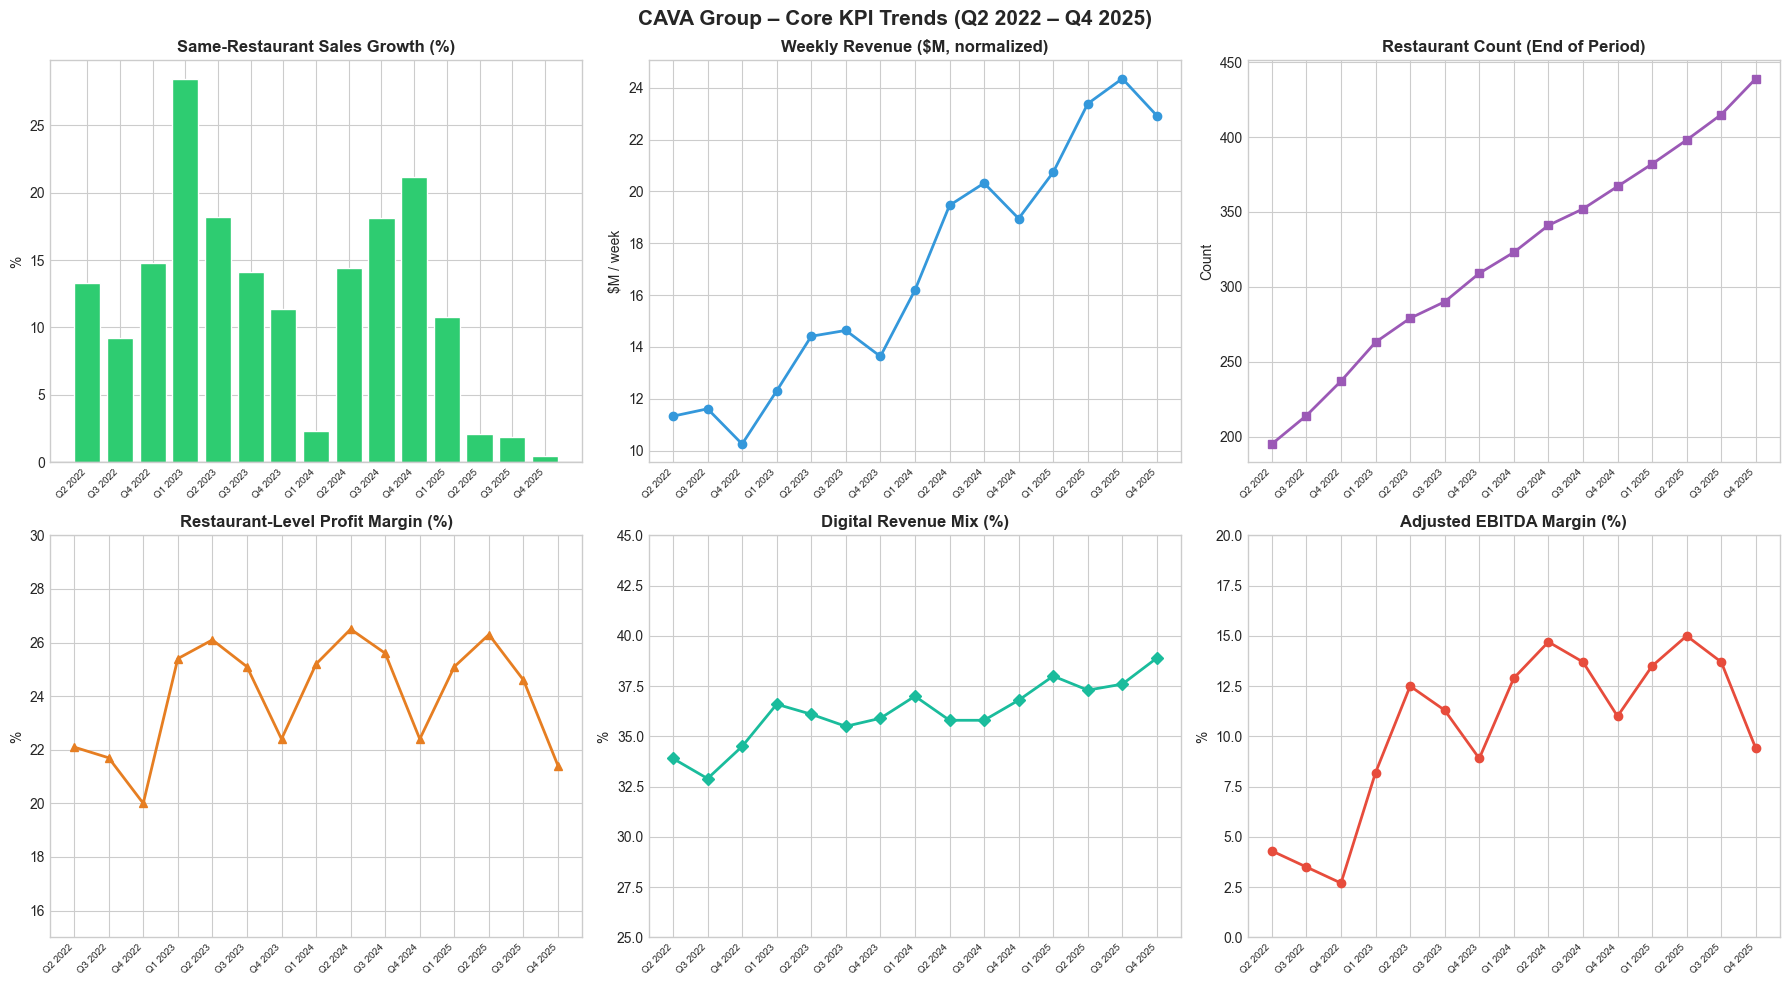

Saved: outputs/figures/cava_kpis.png


In [12]:
BASE_DIR = '/Users/zhangsu/Cava_Investment_Analysis'
FIGURES_DIR = os.path.join(BASE_DIR, 'outputs', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# Visualize core KPIs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CAVA Group – Core KPI Trends (Q2 2022 – Q4 2025)', fontsize=15, fontweight='bold')

x = range(len(q_df))
labels = q_df['quarter']

# SSSG
ax = axes[0, 0]
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in q_df['sssg_pct']]
ax.bar(x, q_df['sssg_pct'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Same-Restaurant Sales Growth (%)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('%')

# Weekly Revenue (normalized)
ax = axes[0, 1]
ax.plot(x, q_df['weekly_revenue_m'], marker='o', color='#3498db', linewidth=2)
ax.set_title('Weekly Revenue ($M, normalized)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('$M / week')

# Restaurant Count
ax = axes[0, 2]
ax.plot(x, q_df['restaurant_count'], marker='s', color='#9b59b6', linewidth=2)
ax.set_title('Restaurant Count (End of Period)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Count')

# Restaurant Margin
ax = axes[1, 0]
ax.plot(x, q_df['restaurant_margin_pct'], marker='^', color='#e67e22', linewidth=2)
ax.set_title('Restaurant-Level Profit Margin (%)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('%')
ax.set_ylim(15, 30)

# Digital Revenue Mix
ax = axes[1, 1]
ax.plot(x, q_df['digital_revenue_mix_pct'], marker='D', color='#1abc9c', linewidth=2)
ax.set_title('Digital Revenue Mix (%)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('%')
ax.set_ylim(25, 45)

# Adj EBITDA Margin
ax = axes[1, 2]
ax.plot(x, q_df['adj_ebitda_margin_pct'], marker='o', color='#e74c3c', linewidth=2)
ax.set_title('Adjusted EBITDA Margin (%)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('%')
ax.set_ylim(0, 20)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cava_kpis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/cava_kpis.png')

---
## Part 2: Google Trends (pytrends)

We use Google Trends as a high-frequency (weekly) proxy for consumer interest in CAVA.
Hypothesis: Rising search interest leads same-restaurant sales growth by 1-2 quarters.

In [65]:
from pytrends.request import TrendReq
import time

pytrends = TrendReq(hl='en-US', tz=360)

# Search terms - CAVA vs fast casual competitors
keywords = ['CAVA restaurant', 'Chipotle', 'Sweetgreen']

pytrends.build_payload(
    keywords,
    cat=0,
    timeframe='2022-01-01 2025-12-31',
    geo='US'
)

time.sleep(1)  # Be polite to the API
trends_df = pytrends.interest_over_time()

if 'isPartial' in trends_df.columns:
    trends_df = trends_df.drop(columns=['isPartial'])

trends_df = trends_df.reset_index()
trends_df.columns = ['date'] + [k.replace(' ', '_').lower() for k in keywords]

print(f'Google Trends data: {len(trends_df)} weeks')
trends_df

Google Trends data: 210 weeks


,date,cava_restaurant,chipotle,sweetgreen
0,2021-12-26,1,77,3
1,2022-01-02,0,77,4
2,2022-01-09,0,70,3
3,2022-01-16,0,62,3
4,2022-01-23,0,62,3
...,...,...,...,...
205,2025-11-30,1,64,4
206,2025-12-07,1,70,4
207,2025-12-14,1,71,3
208,2025-12-21,1,74,2


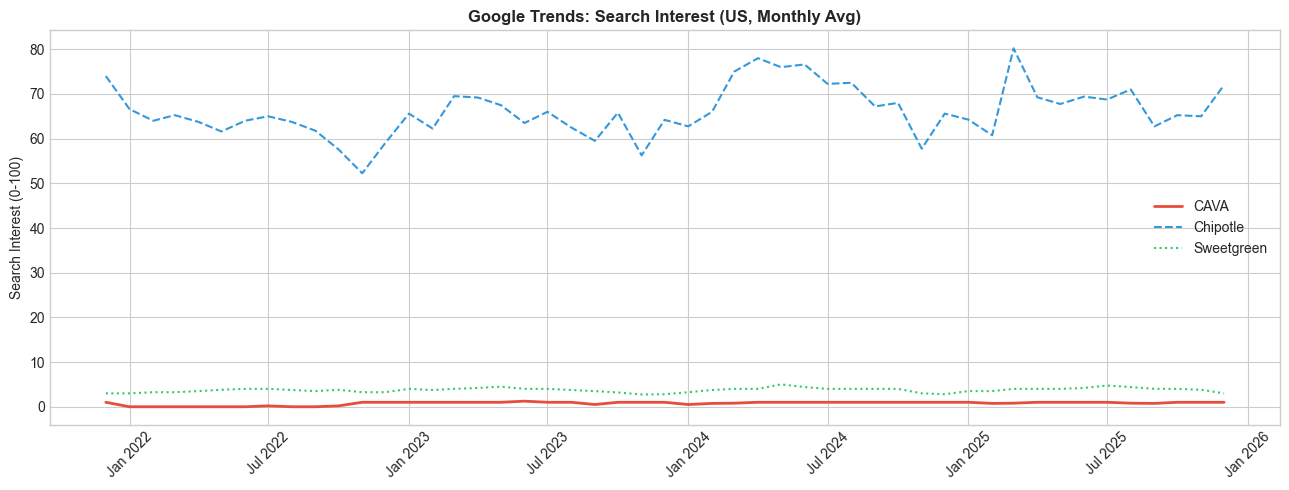

Saved: cava_google_trends.png


In [13]:
# Aggregate to monthly for easier alignment with quarterly financials
trends_df['month'] = trends_df['date'].dt.to_period('M')
trends_monthly = trends_df.groupby('month').mean(numeric_only=True).reset_index()
trends_monthly['month_dt'] = trends_monthly['month'].dt.to_timestamp()

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(trends_monthly['month_dt'], trends_monthly['cava_restaurant'], label='CAVA', linewidth=2, color='#e74c3c')
ax.plot(trends_monthly['month_dt'], trends_monthly['chipotle'], label='Chipotle', linewidth=1.5, linestyle='--', color='#3498db')
ax.plot(trends_monthly['month_dt'], trends_monthly['sweetgreen'], label='Sweetgreen', linewidth=1.5, linestyle=':', color='#2ecc71')
ax.set_title('Google Trends: Search Interest (US, Monthly Avg)', fontweight='bold')
ax.set_ylabel('Search Interest (0-100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cava_google_trends.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cava_google_trends.png')

---
## Part 3: Reddit Sentiment (PRAW)

We scrape Reddit posts mentioning CAVA from food/dining/investing subreddits.
Sentiment is scored using VADER (rule-based, no training required).

#### Reddit Data Collection & Preprocessing for CAVA Investment Analysis

1. Scrapes Reddit posts and comments mentioning CAVA
2. Filters for relevance
3. Computes sentiment using VADER
4. Saves raw and processed data

In [36]:
import requests
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datetime import datetime
import time

# ── Setup ──────────────────────────────────────────────────────────────────────
analyzer = SentimentIntensityAnalyzer()
headers = {'User-Agent': 'cava_research/0.1'}

# ── Step 1: Define relevance filters ──────────────────────────────────────────
CAVA_KEYWORDS = [
    'cava restaurant', 'cava group', 'cava bowl', 'cava grill',
    'cava stock', 'cava earnings', 'cava ipo', 'cava mediterranean',
    'cava menu', 'cava nyc', 'cava food', 'cava pita', '$cava'
]

EXCLUDE_KEYWORDS = [
    'cava dzehverovic', 'cava wine', 'cava sparkling',
    'cava domenico', 'cava agujero', 'trufas de cava'
]

def is_relevant(title, selftext=''):
    """Check if a post is relevant to CAVA the restaurant/stock"""
    text = (title + ' ' + selftext).lower()
    has_cava_keyword = any(kw in text for kw in CAVA_KEYWORDS)
    has_cava = 'cava' in text
    is_english = all(ord(c) < 128 for c in title[:50])
    is_excluded = any(kw in text for kw in EXCLUDE_KEYWORDS)
    return (has_cava_keyword or (has_cava and is_english)) and not is_excluded

def is_strictly_cava(title):
    """Strict filter: title must directly mention CAVA the brand"""
    return bool(pd.Series([title]).str.contains('CAVA|Cava', case=False, na=False).iloc[0])

# ── Step 2: Scrape posts ───────────────────────────────────────────────────────
search_queries = [
    ('investing', 'CAVA stock'),
    ('stocks', 'CAVA restaurant'),
    ('wallstreetbets', 'CAVA'),
    ('SecurityAnalysis', 'CAVA'),
    ('food', 'CAVA restaurant bowl'),
    ('AskNYC', 'CAVA'),
    ('LosAngeles', 'CAVA restaurant'),
    ('fatFIRE', 'CAVA'),
    ('options', 'CAVA'),
]

posts = []
for sub, query in search_queries:
    url = f'https://www.reddit.com/r/{sub}/search.json?q={query}&sort=new&limit=100&restrict_sr=1'
    try:
        r = requests.get(url, headers=headers)
        data = r.json()
        count = 0
        for post in data['data']['children']:
            p = post['data']
            title = p.get('title', '')
            selftext = p.get('selftext', '')

            if not is_relevant(title, selftext):
                continue

            post_sentiment = analyzer.polarity_scores(title + ' ' + selftext)
            posts.append({
                'post_id': p['id'],
                'date': datetime.utcfromtimestamp(p['created_utc']),
                'subreddit': sub,
                'title': title,
                'selftext': selftext[:500],  # truncate long posts
                'score': p['score'],
                'num_comments': p['num_comments'],
                'post_sentiment': post_sentiment['compound'],
                'post_sentiment_pos': post_sentiment['pos'],
                'post_sentiment_neg': post_sentiment['neg'],
                'url': f"https://www.reddit.com{p['permalink']}",
                'is_strictly_cava': is_strictly_cava(title)
            })
            count += 1
        print(f'r/{sub} ({query}): {count} relevant posts')
        time.sleep(1)
    except Exception as e:
        print(f'r/{sub}: error - {e}')

posts_df = pd.DataFrame(posts)
posts_df['date'] = pd.to_datetime(posts_df['date'])
print(f'\nTotal posts collected: {len(posts_df)}')
print(f'Strictly CAVA-related: {posts_df["is_strictly_cava"].sum()}')

# ── Step 3: Scrape comments ────────────────────────────────────────────────────
def scrape_comments(post_url, max_comments=50):
    """Scrape comments from a single Reddit post"""
    url = post_url + '.json?limit=' + str(max_comments)
    try:
        r = requests.get(url, headers=headers)
        data = r.json()
        comments = []
        for comment in data[1]['data']['children']:
            c = comment['data']
            body = c.get('body', '')
            if body and body not in ['[deleted]', '[removed]']:
                comments.append({
                    'body': body,
                    'score': c.get('score', 0),
                    'created_utc': c.get('created_utc', 0)
                })
        return comments
    except Exception:
        return []

# Only scrape comments for strictly CAVA-related posts
cava_posts = posts_df[posts_df['is_strictly_cava'] == True]
print(f'\nScraping comments for {len(cava_posts)} strictly CAVA-related posts...')

comments_data = []
for _, post in cava_posts.iterrows():
    if post['num_comments'] > 0:
        comments = scrape_comments(post['url'])
        for c in comments:
            c_sentiment = analyzer.polarity_scores(c['body'])
            comments_data.append({
                'post_id': post['post_id'],
                'date': post['date'],
                'subreddit': post['subreddit'],
                'comment_body': c['body'][:500],  # truncate
                'comment_score': c['score'],
                'comment_sentiment': c_sentiment['compound'],
                'comment_sentiment_pos': c_sentiment['pos'],
                'comment_sentiment_neg': c_sentiment['neg']
            })
        time.sleep(0.5)

comments_df = pd.DataFrame(comments_data)
print(f'Total comments scraped: {len(comments_df)}')

# ── Step 4: Combined sentiment ─────────────────────────────────────────────────
# Use upvote-weighted sentiment for comments (high-score comments carry more weight)
def weighted_sentiment(group, comments_df):
    scores = comments_df.loc[group.index, 'comment_score'].clip(lower=1)
    return np.average(group, weights=scores)

comment_agg = comments_df.groupby('post_id').agg(
    avg_comment_sentiment=('comment_sentiment', 'mean'),
    weighted_comment_sentiment=('comment_sentiment',
        lambda x: weighted_sentiment(x, comments_df)),
    total_comments_scraped=('comment_sentiment', 'count'),
    avg_comment_score=('comment_score', 'mean'),
    pct_positive_comments=('comment_sentiment',
        lambda x: (x > 0.05).sum() / len(x)),
    pct_negative_comments=('comment_sentiment',
        lambda x: (x < -0.05).sum() / len(x))
).reset_index()

# Merge with posts
combined_df = cava_posts.merge(comment_agg, on='post_id', how='left')

# Combined sentiment: 30% post, 70% weighted comments
combined_df['combined_sentiment'] = (
    combined_df['post_sentiment'] * 0.3 +
    combined_df['weighted_comment_sentiment'].fillna(
        combined_df['post_sentiment']) * 0.7
)


# ── Step 6: Quick summary ──────────────────────────────────────────────────────
print('\n=== SENTIMENT SUMMARY ===')
print(f'Overall avg combined sentiment: {combined_df["combined_sentiment"].mean():.3f}')
print(f'Overall avg post sentiment:     {combined_df["post_sentiment"].mean():.3f}')
print(f'Overall avg comment sentiment:  {combined_df["avg_comment_sentiment"].mean():.3f}')
print(f'\nTop 5 most discussed posts:')
for _, row in combined_df.nlargest(5, 'total_comments_scraped')[
    ['title', 'total_comments_scraped', 'combined_sentiment']].iterrows():
    print(f'  [{row["total_comments_scraped"]} comments] {row["title"][:70]} '
          f'(sentiment: {row["combined_sentiment"]:.2f})')

r/investing (CAVA stock): 6 relevant posts
r/stocks (CAVA restaurant): 11 relevant posts
r/wallstreetbets (CAVA): 55 relevant posts
r/SecurityAnalysis (CAVA): 3 relevant posts
r/food (CAVA restaurant bowl): 1 relevant posts
r/AskNYC (CAVA): 17 relevant posts
r/LosAngeles (CAVA restaurant): 0 relevant posts
r/fatFIRE (CAVA): 0 relevant posts
r/options (CAVA): 15 relevant posts

Total posts collected: 108
Strictly CAVA-related: 61

Scraping comments for 61 strictly CAVA-related posts...
Total comments scraped: 707

=== SENTIMENT SUMMARY ===
Overall avg combined sentiment: 0.309
Overall avg post sentiment:     0.515
Overall avg comment sentiment:  0.243

Top 5 most discussed posts:
  [34.0 comments] $CAVA – DECEMBER SHORT PLAY (Potential Crash and/or Death Spiral) (sentiment: 0.21)
  [30.0 comments] CAVA will melt up (sentiment: 0.22)
  [29.0 comments] CAVA YOLO (sentiment: 0.27)
  [25.0 comments] I am still bullish on CAVA (sentiment: 0.27)
  [25.0 comments] Is this CAVA bull ok? (sentim

#### News Dataset from Finnhub

In [62]:
from dotenv import load_dotenv
import os, requests, pandas as pd, time
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

load_dotenv()
FINNHUB_KEY = os.getenv('FINNHUB_KEY')
analyzer = SentimentIntensityAnalyzer()
BASE_DIR = '/Users/zhangsu/Cava_Investment_Analysis'

# ── Step 1: Fetch all news in date range segments ──────────────────────────────
all_news = []

date_ranges = [
    ('2023-06-01', '2023-12-31'),
    ('2024-01-01', '2024-06-30'),
    ('2024-07-01', '2024-12-31'),
    ('2025-01-01', '2025-06-30'),
    ('2025-07-01', '2025-12-31'),
    ('2026-01-01', '2026-05-01'),
]

for start, end in date_ranges:
    params = {
        'symbol': 'CAVA',
        'from': start,
        'to': end,
        'token': FINNHUB_KEY
    }
    r = requests.get('https://finnhub.io/api/v1/company-news', params=params)
    data = r.json()
    print(f'{start} to {end}: {len(data)} articles')
    all_news.extend(data)
    time.sleep(1)

print(f'\nTotal raw articles: {len(all_news)}')

# ── Step 2: Build DataFrame ────────────────────────────────────────────────────
news_df = pd.DataFrame([{
    'date': pd.to_datetime(n['datetime'], unit='s'),
    'title': n['headline'],
    'summary': n.get('summary', ''),
    'source': n.get('source', ''),
    'url': n.get('url', '')
} for n in all_news if n.get('headline')])

# Remove duplicates
news_df = news_df.drop_duplicates(subset='title').reset_index(drop=True)

# Filter for CAVA-related articles only
news_df = news_df[
    news_df['title'].str.contains('CAVA|Cava', case=False, na=False) |
    news_df['summary'].str.contains('CAVA|Cava', case=False, na=False)
].reset_index(drop=True)

news_df = news_df.sort_values('date').reset_index(drop=True)
print(f'CAVA-related articles after dedup: {len(news_df)}')

# ── Step 3: Clean summary + handle empty summaries ────────────────────────────
news_df['summary'] = news_df['summary'].str.strip()

empty_mask = news_df['summary'] == ''
print(f'Truly empty summaries: {empty_mask.sum()}')

# Fill empty summaries with title
news_df.loc[empty_mask, 'summary'] = news_df.loc[empty_mask, 'title']

# ── Step 4: Sentiment analysis ─────────────────────────────────────────────────
news_df['title_sentiment'] = news_df['title'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)
news_df['summary_sentiment'] = news_df['summary'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

# Combined: 60% title, 40% summary
news_df['combined_sentiment'] = (
    news_df['title_sentiment'] * 0.6 +
    news_df['summary_sentiment'] * 0.4
)

print(f'Zero sentiment rows after fix: {(news_df["combined_sentiment"] == 0).sum()}')
print(f'Avg sentiment: {news_df["combined_sentiment"].mean():.3f}')
print(f'Date range: {news_df["date"].min()} to {news_df["date"].max()}')


2023-06-01 to 2023-12-31: 0 articles
2024-01-01 to 2024-06-30: 0 articles
2024-07-01 to 2024-12-31: 0 articles
2025-01-01 to 2025-06-30: 82 articles
2025-07-01 to 2025-12-31: 235 articles
2026-01-01 to 2026-05-01: 236 articles

Total raw articles: 553
CAVA-related articles after dedup: 373
Truly empty summaries: 45
Zero sentiment rows after fix: 88
Avg sentiment: 0.174
Date range: 2025-05-07 03:56:57 to 2026-05-01 19:44:12


#### Analyst Ratings Downgrade / Upgrade

In [64]:
import yfinance as yf
import pandas as pd

ticker = yf.Ticker('CAVA')

# Upgrades/Downgrades
upgrades = ticker.upgrades_downgrades.reset_index()
upgrades.columns = [c.lower() for c in upgrades.columns]
upgrades['date'] = pd.to_datetime(upgrades['gradedate'])
upgrades = upgrades.sort_values('date').reset_index(drop=True)

print(f'Total analyst actions: {len(upgrades)}')
print(upgrades.tail(10))


Total analyst actions: 164
              gradedate            firm       tograde     fromgrade action  \
154 2026-03-09 12:14:42  Wolfe Research    Outperform                 init   
155 2026-03-26 13:14:10      Guggenheim           Buy                 init   
156 2026-04-02 12:09:42          Mizuho       Neutral       Neutral   main   
157 2026-04-02 12:23:11        TD Cowen           Buy           Buy   main   
158 2026-04-13 17:58:56   Goldman Sachs       Neutral       Neutral   main   
159 2026-04-20 12:15:00         Keybanc    Overweight    Overweight   main   
160 2026-04-20 12:45:40       Benchmark           Buy           Buy   main   
161 2026-04-21 15:16:29  Morgan Stanley  Equal-Weight  Equal-Weight   main   
162 2026-04-24 15:41:55       JP Morgan    Overweight    Overweight   main   
163 2026-05-01 16:04:58     RBC Capital    Outperform    Outperform   main   

    pricetargetaction  currentpricetarget  priorpricetarget  \
154         Announces                93.0          

---
## Part 4: Save All Data to CSV

In [37]:
import os

BASE_DIR = '/Users/zhangsu/Cava_Investment_Analysis'

os.makedirs(f'{BASE_DIR}/data/raw', exist_ok=True)
os.makedirs(f'{BASE_DIR}/data/processed', exist_ok=True)
os.makedirs(f'{BASE_DIR}/outputs/figures', exist_ok=True)

# ── RAW DATA ──────────────────────────────────────────
price_df.to_csv(f'{BASE_DIR}/data/raw/cava_stock_price_raw.csv', index=False)
trends_df[['date', 'cava_restaurant', 'chipotle', 'sweetgreen']].to_csv(
    f'{BASE_DIR}/data/raw/cava_google_trends_weekly_raw.csv', index=False)
posts_df.to_csv(f'{BASE_DIR}/data/raw/cava_reddit_posts_raw.csv', index=False)
comments_df.to_csv(f'{BASE_DIR}/data/raw/cava_reddit_comments_raw.csv', index=False)
news_df.to_csv(f'{BASE_DIR}/data/raw/cava_news_raw.csv', index=False)
upgrades.to_csv(f'{BASE_DIR}/data/raw/cava_analyst_actions.csv', index=False)

# ── PROCESSED DATA ────────────────────────────────────
q_df.to_csv(f'{BASE_DIR}/data/processed/cava_quarterly_fundamentals.csv', index=False)
trends_monthly.to_csv(f'{BASE_DIR}/data/processed/cava_google_trends_monthly.csv', index=False)
combined_df.to_csv(f'{BASE_DIR}/data/processed/cava_reddit_combined_sentiment.csv', index=False)

print('All files saved successfully!')

All files saved successfully!
